# CNN-based multiclass classifier

### Description
###

In [1]:
# For the sake of convenience, just single file for now.
# ============
## TIMESTAMP @ 2024-11-07T16:34:02

# Exp with transfer learning approach
# Pretrained weight from Imagenet
# Optimizer: AdamW, Adamax
"""
Experiment Code:
Model: EfficientNetB3 
Pretrained weights: imagenet
Training type: Training all layers.
Output layers: Config_1
Regularizer layer: None
Data augmentation: Yes
Optimizer: Adamax
LearningRate Scheduler: Consine decay
LearningRate Scheduler opt: 0.9, 0.1
epochs: 100
batchsize: 32
"""
# Import necessary libs

import os, io
import datetime
import time
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import logging
import random
import string
# These lib should be placed at the same level at the notebook
import dev_configuration
import dev_dataprocesses
import itertools

2024-12-16 18:18:38.824249: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-16 18:18:38.824267: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-16 18:18:38.824272: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-16 18:18:38.828026: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
## Configuration

In [3]:
randomState_value = 2024

# Dataset configuration
datasets  = ['chest_xray_small', 'chest-xray-full', 'sport-balls']
dataset_name = 'sport-balls'
dataset_original_path = f"./datasets/{dataset_name}/"
test_split_value = 0.2 # split ratio of test from the given data source
val_split_value = 0.3 # split ratio of validation from the given data source
# keras datagenerators configuration
default_xcol_value = 'filepath'
default_ycol_value = 'label'
isShuffle = True

# Debug flags
# legacy flags
isDebug = False
isVerbose = True
is_config_exp = False # Disable model archs definition list
# Image size configuration
# legacy
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
# Model configuration
# Learning configuration
model_loss_opt = 'categorical_crossentropy'
learning_rate = 0.001
# learning cosine decay rate
decay_rate = 0.9
decay_alpha_value = 0.1

# default setting for long run
enableEarlyStopping = False
enableEarlyStopping_threshold = 10
epochs = 200
batch_size = 32 # GPU RAM should be at least 24GB
if isDebug:
    # Debug run
    epochs = 10
    batch_size = 16
else:
    # Normal run
    epochs = 100
    batch_size = 32 # Run on small gpu portion
# for transfer learning/finetuning
pretrained_weights = 'imagenet' # Pretrained weights
frozen_weights = False # True: Freeze all base layers. False: otherwise.
# For regulariser layers
kernel_l_value = 0.001
act_l_value = 0.001
drop_out_value_1 = 0.5
drop_out_value_2 = 0.3
drop_out_value_3 = 0.1
models_archs = ['ModelCNNExp1', 'ModelCNNExp2', 'ModelCNNExp3', 'ModelCNNExp4']

In [4]:
# Logging and artifacts configuration
# Generate unique exp string
digits = random.choices(string.digits, k=2)
letters = random.choices(string.ascii_uppercase, k=9)
uniq_sample = f"".join(random.sample(digits + letters, 9))

# Setting up folders and logging
exp_base_dir = f"./experiments/"
model_sel = 'EfficientNetB3'
# configurations for output layers after base-layer
config_output_arc = 'config_1'

augmentation_opts = {
            'rescale': None, # Remember to set None if model is EfficientNet
            'rotation_range': 0.45,
            'width_shift_range': 0.1,
            'height_shift_range': 0.1,
            'zoom_range': 0.3,
            'horizontal_flip': True,
            'vertical_flip': True,
        }
if model_sel == 'EfficientNetB3':
    augmentation_opts['rescale'] = None

#augmentation_options = f"rescale width_shift_range height_shift_range zoom_range horizontal_flip=True vertical_flip=True"
augmentation_options = f"".join([f"{key}_{augmentation_opts[key]}_" for key in augmentation_opts.keys()])

# augmentation_options = f"augs_rescale rot=no horizontal_flip=True vertical_flip=True"
#augmentation_options = f"augs_rescale rot=no horizontal_flip=no vertical_flip=no"
other_options = (f"_no_pool_in_base_{config_output_arc}_activity_reg_{act_l_value}_kernel_reg_{kernel_l_value}_dropout_0.3_0.3"
                 f"\nlearning rate decay: Adamax, "
                 f"\n decay_rate_{decay_rate}_alpha_{decay_alpha_value}")


In [5]:
## Preparation

In [6]:
current_datestamp = datetime.datetime.now().strftime("%Y%m%d")
exp_folder = f"{model_sel}-{current_datestamp}_{uniq_sample}"

logs_text_dir = os.path.join(exp_base_dir, exp_folder, "logs")
checkpoints_dir = os.path.join(exp_base_dir, exp_folder, "checkpoints")

current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_filename = f"{logs_text_dir}/{model_sel}-{current_timestamp}.log"

if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir, exist_ok=True)

if not os.path.exists(logs_text_dir):
    os.makedirs(logs_text_dir, exist_ok=True)

# Create a logger
logger = logging.getLogger('my_logger')
logger.setLevel(logging.DEBUG)

# Create a formatter to define the log format
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')

# Create a file handler to write logs to a file
file_handler = logging.FileHandler(log_filename)
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(formatter)

# Create a stream handler to print logs to the console
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)  # You can set the desired log level for console output
console_handler.setFormatter(formatter)

# Add the handlers to the logger
logger.addHandler(file_handler)
logger.addHandler(console_handler)

logger.info(f"Datetime: {current_timestamp}"
            f"\n Setup all folders and files:"
            f"\n Unique expname: {uniq_sample}"
            f"\n exp_folder: {exp_folder}"
            f"\n -logs_text_dir dir: {logs_text_dir}"
            f"\n -checkpoints_dir : {checkpoints_dir}")


2024-12-16 18:18:40,623 - INFO - Datetime: 20241216-181840
 Setup all folders and files:
 Unique expname: 3ZYHSIB0H
 exp_folder: EfficientNetB3-20241216_3ZYHSIB0H
 -logs_text_dir dir: ./experiments/EfficientNetB3-20241216_3ZYHSIB0H/logs
 -checkpoints_dir : ./experiments/EfficientNetB3-20241216_3ZYHSIB0H/checkpoints


In [7]:
## Helpers function

In [8]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Oranges,
                          figname='figname.png'):
    plt.figure(figsize=(10, 10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized Confusion Matrix')
    else:
        print('Confusion Matrix, Without Normalization')
    print(cm)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(fig_name)

def get_model_summary(model):
    stream = io.StringIO()
    model.summary(print_fn=lambda x: stream.write(x + '\n'))
    summary_string = stream.getvalue()
    stream.close()
    return summary_string

class LearningRateLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(self.model.optimizer.iterations)
        logs['learning_rate'] = float(tf.keras.backend.get_value(lr))

In [9]:
# Generate data for training

In [10]:
## Data preparation

In [11]:
loaded_datasets = dev_dataprocesses.load_dataset(preconfigured_dataset=dataset_name)

train_data, val_data, test_data = dev_dataprocesses.data_generators(
    datasource=loaded_datasets,
    data_generator='keras',
    test_split_value = test_split_value,
    val_split_value = val_split_value,
    randomState_value = randomState_value,
    default_xcol_value = default_xcol_value,
    default_ycol_value = default_ycol_value,
    batch_size = batch_size,
    isShuffle = isShuffle,
    augmentation_opts = augmentation_opts
)

Processing ./datasets/sport-balls
Processing train set
Processing test set
 processes completed
 3

 Label: train 
Length is : 7328
Sample head: 
                                             filepath     label
0  ./datasets/sport-balls/train/baseball/baseball...  baseball
1  ./datasets/sport-balls/train/baseball/baseball...  baseball
2  ./datasets/sport-balls/train/baseball/baseball...  baseball
3  ./datasets/sport-balls/train/baseball/baseball...  baseball
4  ./datasets/sport-balls/train/baseball/baseball...  baseball
Sample shape: 
 (7328, 2)
Value counts: 
 label
billiard_ball        646
table_tennis_ball    620
football             604
cricket_ball         581
golf_ball            549
hockey_ball          530
rugby_ball           493
tennis_ball          490
bowling_ball         440
volleyball           432
shuttlecock          429
baseball             400
hockey_puck          390
american_football    384
basketball           340
Name: count, dtype: int64==================

 Label:

In [12]:
## Models definition

In [13]:
# Model arch library
# Customized model arch


In [14]:
logger.info(f"Training {model_sel} model  with new configuration")

if model_sel == 'VGG16':
    base_model = keras.applications.VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=img_shape,
    )
elif model_sel == 'VGG19':
    base_model = keras.applications.VGG19(
        include_top=False,
        weights='imagenet',
        input_shape=img_shape,
    )
elif model_sel == 'EfficientNetB3':
    base_model = keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
        # pooling='max'
    )
# elif model_sel == 'ModelCNNExp1':
#     base_model = ModelCNNExp1
# elif model_sel == 'ModelCNNExp2':
#     base_model = ModelCNNExp1
# elif model_sel == 'ModelCNNExp3':
#     base_model = ModelCnnExp3
# elif model_sel == 'ModelCNNExp4':
#     base_model = ModelCnnExp4
else:
    base_model = keras.applications.VGG19(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
    )

# if model_sel == 'ModelCNNExp1' or model_sel == 'ModelCNNExp2':
if model_sel == 'ModelCNNExp1':
    logger.info(f"Training {model_sel} model  from scratch")
    model_new = keras.models.Sequential([
        # base_model,
        keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=img_shape),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPool2D(pool_size=(3, 3)),

        keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPool2D(pool_size=(2, 2)),

        keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPool2D(pool_size=(2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(1024, activation='relu'),
        ## TIMESTAMP @ 2024-12-13T17:52:43
        ## author: phuocddat
        ## start
        # Add regularizers layers to reduce overfitting
        keras.layers.Dropout(drop_out_value_2), # medium dropout
        keras.layers.Dense(512, activation='relu',
                           kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                           activity_regularizer=keras.regularizers.l1(l=act_l_value)),
        keras.layers.Dropout(drop_out_value_2), # medium dropout
        ## end --
        keras.layers.Dense(15, activation='softmax')
    ])
##
## Removed other types of model archs which are not as efficient as the ModelCNNEXp1
## ====
elif model_sel == 'EfficientNetB3':
    if frozen_weights:
        logger.info(f"Perform training with frozen weight with {model_sel}")
    else:
        logger.info(f"Perform training with no pretrained-weights {model_sel}")

    # Freeze pretrained weight from base_model layers.
    ## TIMESTAMP @ 2024-12-15T16:45:03
    ## author: phuocddat
    ## start
    # Disable trainable setting - default
    # base_model.trainable = False
    ## end --

    logger.info(f"Processing {model_sel} with {config_output_arc} for output block")
    if config_output_arc == 'config_1':
        model_new = keras.models.Sequential([
            base_model,
            # Config 1
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dense(15, activation='softmax')
        ])
    elif config_output_arc == 'config_2':
        model_new = keras.models.Sequential([
            base_model,
            # Config 2
            ## TIMESTAMP @ 2024-12-12T10:38:52
            ## author: phuocddat
            ## start
            ## end --
            keras.layers.BatchNormalization(),
            keras.layers.Dense(256,
                               # kernel_regularizer=keras.regularizers.l2(0.001),
                               # activity_regularizer=keras.regularizers.l1(0.001),
                               activation='relu', ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout - 0.3
            keras.layers.Dense(15, activation="softmax")
        ])
    elif config_output_arc == 'config_3':
        model_new = keras.models.Sequential([
            base_model,
            # Config 3
            # Add regularizers to reduce overfitting
            keras.layers.Dense(512, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout - 0.5
            keras.layers.Dense(15, activation='softmax')
            ## end --
        ])
    elif config_output_arc == 'config_4':
        model_new = keras.models.Sequential([
            base_model,
            # Config 4
            # Add regularizes to reduce overfitting
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            keras.layers.Dense(512, activation='relu',
                               #kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               #activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(15, activation='softmax')
        ])
    elif config_output_arc == 'config_5':
        model_new = keras.models.Sequential([
            # Config 5
            base_model,
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            # keras.layers.Dropout(0.3),
            keras.layers.Dense(512, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout
            keras.layers.Dense(256, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy drop out
            keras.layers.Dense(64, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            ## end --
            keras.layers.Dense(15, activation='softmax')
        ])
    else:
        logger.info(f"Not implemented {config_output_arc}")
        logger.info(f"Using one of drafting version below")
        model_new = keras.models.Sequential([
            # Config 5
            base_model,
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            # keras.layers.Dropout(0.3),
            keras.layers.Dense(512, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout
            keras.layers.Dense(256, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy drop out
            keras.layers.Dense(64, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            ## end --
            keras.layers.Dense(15, activation='softmax')
        ])
else:
    if frozen_weights:
        logger.info(f"Perform training with frozen weight with {model_sel}")
    else:
        logger.info(f"Perform training with no pretrained-weights {model_sel}")
    # Freeze pretrained weight from base_model layers.
    # base_model.trainable = not frozen_weights
    model_new = keras.models.Sequential([
        base_model,
        # Config 1
        keras.layers.Flatten(),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(15, activation='softmax')
    ])


2024-12-16 18:18:40,779 - INFO - Training EfficientNetB3 model  with new configuration
2024-12-16 18:18:40.953032: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-16 18:18:40.974247: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-16 18:18:40.979799: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero.

In [15]:
## Learning strategies

In [16]:
total_steps = len(train_data) * epochs
decay_steps = total_steps * decay_rate
logger.info(f"Total steps: {total_steps}"
      f"\n_decay steps: {decay_steps}")

cosine_decay_scheduler = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate,
    decay_steps=decay_steps,
    alpha=decay_alpha_value
)

2024-12-16 18:18:44,153 - INFO - Total steps: 16100
_decay steps: 14490.0


In [17]:
## Compile and fit

In [18]:
current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
exp_save_name = (f"{current_timestamp}___"
                 f"model_{model_sel}_{config_output_arc}_{pretrained_weights}_frozen_"
                 f"Adamax_bs_{batch_size}_frozen_{str(frozen_weights)}_cosine__aug")
checkpoint_path = f"{exp_save_name}.h5"
logger.info(f"epochs {dev_configuration.epochs}"
            f"\n batch size = {batch_size}"
            f"\n other options: {other_options} "
            f"\n augmentation: {augmentation_options}"
            f"\n Checkpoint: {checkpoint_path}")

my_callbacks = [
    # keras.callbacks.EarlyStopping(patience=enableEarlyStopping_threshold) if enableEarlyStopping else None,
    LearningRateLogger(),
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )
]
# Exp model training

2024-12-16 18:18:44,186 - INFO - epochs 200
 batch size = 32
 other options: _no_pool_in_base_config_1_activity_reg_0.001_kernel_reg_0.001_dropout_0.3_0.3
learning rate decay: Adamax, 
 decay_rate_0.9_alpha_0.1 
 augmentation: rescale_None_rotation_range_0.45_width_shift_range_0.1_height_shift_range_0.1_zoom_range_0.3_horizontal_flip_True_vertical_flip_True_
 Checkpoint: 20241216-181844___model_EfficientNetB3_config_1_imagenet_frozen_Adamax_bs_32_frozen_False_cosine__aug.h5


In [19]:
model_new.compile(optimizer=tf.optimizers.Adamax(learning_rate=cosine_decay_scheduler),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_summary_string = get_model_summary(model_new)
logger.info(model_summary_string)

start_time = time.time()

training_exper_model_eff = model_new.fit(train_data,
                                         epochs=epochs,
                                         validation_data=val_data,
                                         verbose=1,
                                         callbacks=my_callbacks,
                                         #use_multiprocessing = True
                                         )
logger.info(f"Training finished in {time.time() - start_time} seconds")

2024-12-16 18:18:44,459 - INFO - Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb3 (Functional  (None, 7, 7, 1536)        10783535  
 )                                                               
                                                                 
 flatten (Flatten)           (None, 75264)             0         
                                                                 
 dense (Dense)               (None, 1024)              77071360  
                                                                 
 dense_1 (Dense)             (None, 256)               262400    
                                                                 
 dense_2 (Dense)             (None, 64)                16448     
                                                                 
 dense_3 (Dense)             (None, 32)                2080      
                       

Epoch 1/100


2024-12-16 18:18:59.287075: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnetb3/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2024-12-16 18:19:01.503024: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2024-12-16 18:19:02.262170: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x72298c021750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-12-16 18:19:02.262187: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2024-12-16 18:19:02.264746: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-12-16 18:19:02.323181: I ./tensorflow/compiler/jit/device_

161/161 [==============================] - ETA: 0s - loss: 1.7140 - accuracy: 0.4942

/home/phuocddat/git-repo/msc_ai/chest_xray/env_chest_xray/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


161/161 [==============================] - 85s 339ms/step - loss: 1.7140 - accuracy: 0.4942 - val_loss: 0.9955 - val_accuracy: 0.7194 - learning_rate: 9.9973e-04
Epoch 2/100
161/161 [==============================] - 54s 334ms/step - loss: 0.7966 - accuracy: 0.7742 - val_loss: 0.7201 - val_accuracy: 0.8004 - learning_rate: 9.9891e-04
Epoch 3/100
161/161 [==============================] - 54s 334ms/step - loss: 0.5686 - accuracy: 0.8444 - val_loss: 0.6500 - val_accuracy: 0.8299 - learning_rate: 9.9755e-04
Epoch 4/100
161/161 [==============================] - 54s 335ms/step - loss: 0.4361 - accuracy: 0.8750 - val_loss: 0.6055 - val_accuracy: 0.8472 - learning_rate: 9.9563e-04
Epoch 5/100
161/161 [==============================] - 53s 332ms/step - loss: 0.3607 - accuracy: 0.8951 - val_loss: 0.5789 - val_accuracy: 0.8590 - learning_rate: 9.9318e-04
Epoch 6/100
161/161 [==============================] - 54s 334ms/step - loss: 0.3014 - accuracy: 0.9123 - val_loss: 0.5037 - val_accuracy: 0.8

2024-12-16 19:46:24,250 - INFO - Training finished in 5259.789693117142 seconds


In [20]:
## Evaluating
# Full Evaluate model
ts_length = len(test_data)
test_batch_size = max(
    sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length % n == 0 and ts_length / n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model_new.evaluate(train_data, steps=test_steps, verbose=1)
valid_score = model_new.evaluate(val_data, steps=test_steps, verbose=1)
test_score = model_new.evaluate(test_data, steps=test_steps, verbose=1)
print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 [==============================] - 0s 134ms/step - loss: 2.1334 - accuracy: 0.8750
Train Loss:  9.952661457646172e-06
Train Accuracy:  1.0
--------------------
Validation Loss:  0.17036201059818268
Validation Accuracy:  0.96875
--------------------
Test Loss:  2.1333847045898438
Test Accuracy:  0.875


In [21]:
## Plots and results

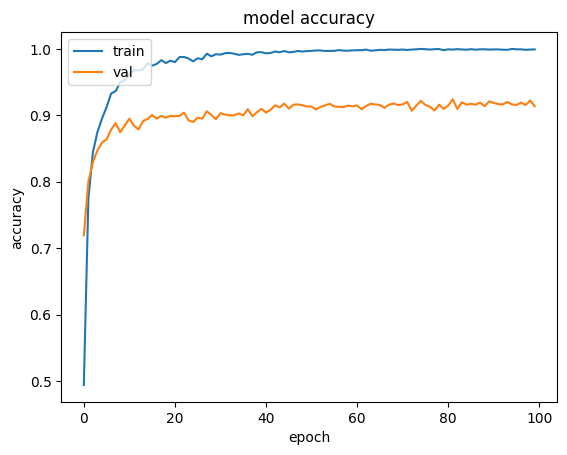

2024-12-16 19:46:26,019 - INFO - Export plot results: ./experiments/EfficientNetB3-20241216_3ZYHSIB0H/logs/20241216-194625_aug_model_EfficientNetB3_imagenet_frozen_False_ep200_bs_32_acc_tr1.0_va0.96875_te0.875_accuracy_plot.png


<Figure size 640x480 with 0 Axes>

In [22]:
metrics_string = f"acc_tr{train_score[1]}_va{valid_score[1]}_te{test_score[1]}"

current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_"
            f"{metrics_string}_"
            f"accuracy_plot.png")

plt.plot(training_exper_model_eff.history['accuracy'])
plt.plot(training_exper_model_eff.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
plt.savefig(fig_name)
logger.info(f"Export plot results: {fig_name}")

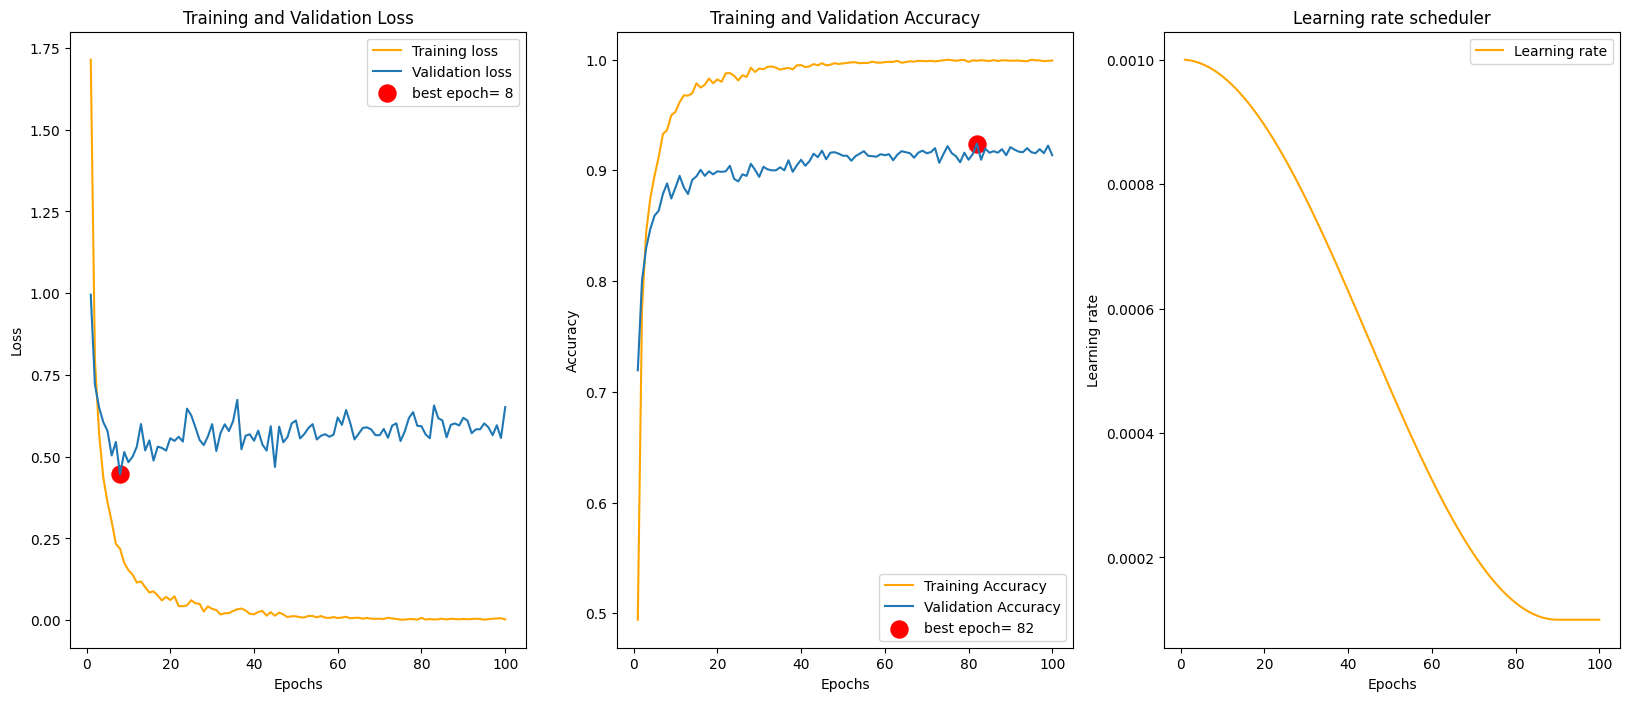

2024-12-16 19:46:26,326 - INFO - Export plot results: ./experiments/EfficientNetB3-20241216_3ZYHSIB0H/logs/20241216-194625_aug_model_EfficientNetB3_imagenet_frozen_False_ep200_bs_32_cosine_decay_scheduler_accuracy_loss_acc_tr1.0_va0.96875_te0.875_plots.png
2024-12-16 19:46:26,327 - INFO - Train loss: 9.952661457646172e-06
Train Accuracy: 1.0
Validation loss: 0.17036201059818268
Validation Accuracy: 0.96875
Test Loss: 2.1333847045898438
Test Accuracy: 0.875


<Figure size 640x480 with 0 Axes>

In [23]:
# Plot
fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_"
            f"{metrics_string}"
            f"_plots.png")
# Define needed variables
tr_acc = training_exper_model_eff.history['accuracy']
tr_loss = training_exper_model_eff.history['loss']
val_acc = training_exper_model_eff.history['val_accuracy']
val_loss = training_exper_model_eff.history['val_loss']

learning_rate_logs = training_exper_model_eff.history['learning_rate']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
# index_lr = np.argmin(learning_rate)

loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

Epochs = [i + 1 for i in range(len(tr_acc))]

# Plot training history
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.plot(Epochs, tr_loss, 'orange', label='Training loss')
plt.plot(Epochs, val_loss, label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='red', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(Epochs, tr_acc, 'orange', label='Training Accuracy')
plt.plot(Epochs, val_acc, label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='red', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(Epochs, learning_rate_logs, 'orange', label='Learning rate')
plt.title('Learning rate scheduler')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.legend()
plt.show()
plt.savefig(fig_name)
logger.info(f"Export plot results: {fig_name}")

try:
    logger.info(f"Train loss: {train_score[0]}"
                f"\nTrain Accuracy: {train_score[1]}"
                f"\nValidation loss: {valid_score[0]}"
                f"\nValidation Accuracy: {valid_score[1]}"
                f"\nTest Loss: {test_score[0]}"
                f"\nTest Accuracy: {test_score[1]}")
except Exception as e:
    print(f"Unable to log evaluation score"
          f"\n Reason: {e}")






In [24]:
# Compute confusion matrix and plot figure

/tmp/ipykernel_247583/2623250881.py:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  preds = model_new.predict_generator(test_data)
2024-12-16 19:46:30,817 - INFO -                    precision    recall  f1-score   support

american_football       0.93      0.85      0.89        96
         baseball       0.92      0.89      0.90       100
       basketball       0.87      0.95      0.91        86
    billiard_ball       0.98      0.92      0.95       162
     bowling_ball       0.89      0.86      0.88       111
     cricket_ball       0.99      0.91      0.95       146
         football       0.97      0.97      0.97       151
        golf_ball       0.89      0.91      0.90       138
      hockey_ball       0.82      0.87      0.85       133
      hockey_puck       0.88      0.86      0.87        98
       rugby_ball       0.86      0.93      0.89       124
      shuttlecock    

[1 1 1 ... 8 8 7]
Confusion Matrix, Without Normalization
[[ 82   1   1   0   0   0   1   0   0   0   8   1   0   1   1]
 [  1  89   0   0   0   0   1   3   2   0   1   1   0   1   1]
 [  0   0  82   0   0   0   0   0   1   0   0   0   2   0   1]
 [  0   2   1 149   3   1   0   0   0   2   1   2   1   0   0]
 [  0   0   0   1  96   1   2   0   2   1   3   1   2   0   2]
 [  2   2   1   0   0 133   0   1   0   2   0   1   0   4   0]
 [  1   0   0   0   0   0 146   0   2   0   1   0   0   0   1]
 [  0   0   1   0   1   0   0 126   6   0   3   0   0   1   0]
 [  0   2   0   1   1   0   0   6 116   2   0   0   4   1   0]
 [  1   0   2   1   3   0   1   0   4  84   0   0   0   0   2]
 [  1   0   5   0   0   0   0   1   0   2 115   0   0   0   0]
 [  0   1   0   0   0   0   0   2   0   0   0 104   1   0   0]
 [  0   0   0   0   3   0   0   1   5   2   1   0 143   0   1]
 [  0   0   0   0   0   0   0   2   3   1   0   1   0 115   1]
 [  0   0   1   0   1   0   0   0   0   0   1   1   1   0 10

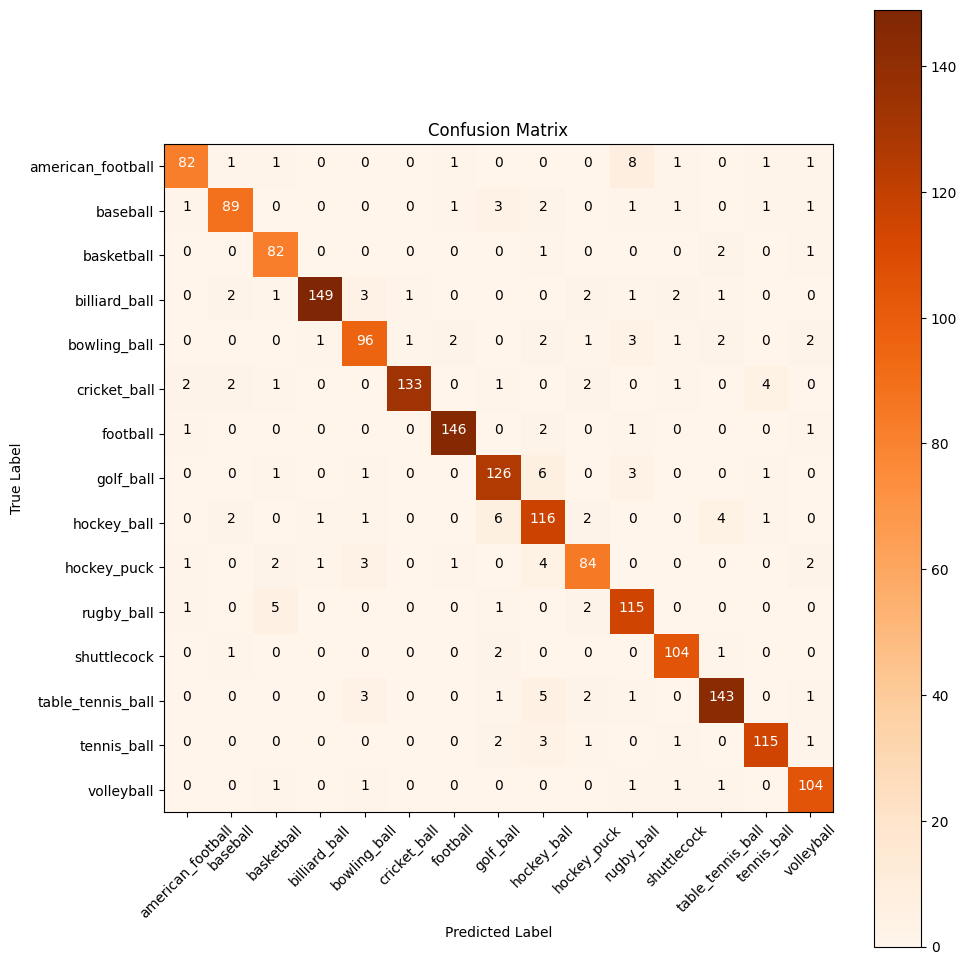

In [25]:
preds = model_new.predict_generator(test_data)
y_pred = np.argmax(preds, axis=1)
print(y_pred)
target_names = ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball', 'cricket_ball',
                'football', 'golf_ball', 'hockey_ball', 'hockey_puck', 'rugby_ball', 'shuttlecock',
                'table_tennis_ball', 'tennis_ball', 'volleyball']
# Classification report
logger.info(classification_report(test_data.classes, y_pred, target_names=target_names))

fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_"
            f"{metrics_string}"
            f"_confusion_mat.png")
# Confusion matrix
cm = confusion_matrix(test_data.classes, y_pred)
plot_confusion_matrix(cm=cm, classes=target_names, title='Confusion Matrix', figname=fig_name)




In [26]:
# Save everything
acc = test_score[1] * 100
save_path = checkpoints_dir

# Save history
history_filename = f"{logs_text_dir}/{model_sel}-{current_timestamp}.npy"
np.save(history_filename, training_exper_model_eff.history)

logger.info(f'model training history was saved as {history_filename}')

# Save model
save_id = str(f'{exp_save_name}-{"%.2f" % round(acc, 2)}.h5')
model_save_loc = os.path.join(save_path, save_id)
model_new.save(model_save_loc)
logger.info(f'model was saved as {model_save_loc}')

# Save weights
weight_save_id = str(f'{exp_save_name}-{"%.2f" % round(acc, 2)}-weights.h5')
weights_save_loc = os.path.join(save_path, weight_save_id)
model_new.save_weights(weights_save_loc)
logger.info(f'weights were saved as {weights_save_loc}')

elapsed_time = time.time() - start_time
logger.info(f"{current_timestamp}: Processing time: {elapsed_time} seconds. Saved plot to {fig_name} \n")
logger.info(time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))
logger.info(f"Finished!")


2024-12-16 19:46:31,513 - INFO - model training history was saved as ./experiments/EfficientNetB3-20241216_3ZYHSIB0H/logs/EfficientNetB3-20241216-194625.npy
/home/phuocddat/git-repo/msc_ai/chest_xray/env_chest_xray/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2024-12-16 19:46:32,870 - INFO - model was saved as ./experiments/EfficientNetB3-20241216_3ZYHSIB0H/checkpoints/20241216-181844___model_EfficientNetB3_config_1_imagenet_frozen_Adamax_bs_32_frozen_False_cosine__aug-87.50.h5
2024-12-16 19:46:33,324 - INFO - weights were saved as ./experiments/EfficientNetB3-20241216_3ZYHSIB0H/checkpoints/20241216-181844___model_EfficientNetB3_config_1_imagenet_frozen_Adamax_bs_32_frozen_False_cosine__aug-87.50-weights.h5
2024-12-16 19:46:33,325 - INFO - 202